# Exploratory Data Analysis (EDA) & Data Preparation - Skripsi

Notebook ini berfungsi secara khusus sebagai lampiran akademis untuk Bab 3 dan Bab 4 Skripsi. Notebook ini tidak terhubung dan tidak mempengaruhi sistem utama yang dideploy di Streamlit.

Tujuan utama notebook ini adalah untuk membuktikan secara formal proses inspeksi data, pencarian nilai kosong, pengecekan duplikat, statistika deskriptif, dan simulasi proses Data Preparation.

## 1. Import Library

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

## 2. Memuat Data
Membaca data historis saham BBCA dari file CSV cadangan yang sudah tersedia.

In [2]:
# Membaca data CSV
df = pd.read_csv('bbca_cadangan.csv')

# Mengubah tipe kolom Date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Close,High,Low,Open,Volume
0,2016-03-31,2100.871826,2104.820833,2081.126790,2096.922819,107951000
1,2016-04-01,2100.871826,2104.820833,2085.075797,2100.871826,73802500
2,2016-04-04,2104.821045,2120.617075,2100.872037,2120.617075,49630500
3,2016-04-05,2104.821045,2124.566083,2100.872037,2104.821045,83700500
4,2016-04-06,2061.381592,2120.616695,2061.381592,2100.871661,89264000


In [3]:
df.tail()

,Date,Close,High,Low,Open,Volume
2455,2026-03-17,6490.854492,6538.757477,6466.903000,6466.903000,160903900
2456,2026-03-25,6610.612305,6634.563799,6395.048860,6395.048860,314281100
2457,2026-03-26,6586.660645,6682.466618,6562.709151,6610.612138,145934900
2458,2026-03-27,6419.000000,6562.708955,6419.000000,6490.854478,283556500
2459,2026-03-30,6450.000000,6500.000000,6350.000000,6400.000000,242278100


## 3. Pengecekan Informasi dan Tipe Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2460 non-null   datetime64[ns]
 1   Close   2460 non-null   float64       
 2   High    2460 non-null   float64       
 3   Low     2460 non-null   float64       
 4   Open    2460 non-null   float64       
 5   Volume  2460 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 115.4 KB


## 4. Pengecekan Data Kosong (Missing Values)

In [5]:
print("Jumlah Data Kosong pada setiap kolom:")
df.isnull().sum()

Jumlah Data Kosong pada setiap kolom:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 5. Pengecekan Data Duplikat

In [6]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris data yang terduplikasi: {jumlah_duplikat}")

Jumlah baris data yang terduplikasi: 0


## 6. Describe

In [7]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,2460,2460.000000,2460.000000,2460.000000,2460.000000,2.460000e+03
mean,2021-02-28 18:49:10.243902464,5741.608708,5794.075988,5690.732787,5742.788803,8.945250e+07
min,2016-03-31 00:00:00,2034.310669,2042.272787,2010.424438,2014.405517,0.000000e+00
25%,2018-09-02 06:00:00,3867.207581,3908.668730,3827.996723,3864.843167,5.560182e+07
50%,2021-02-13 00:00:00,5515.328613,5560.126525,5472.423491,5525.019045,7.555940e+07
75%,2023-08-24 06:00:00,7756.506226,7832.138498,7688.429534,7768.732565,1.042561e+08
max,2026-03-30 00:00:00,10060.582031,10060.582031,9899.796260,10014.642719,1.432993e+09
std,NaN,2163.853474,2182.925787,2147.228358,2164.437017,7.194273e+07


In [8]:
df.shape

(2460, 6)

## 7. Visualisasi Tren Data Historis

In [9]:
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(
    x=df['Date'], 
    y=df['Close'], 
    name="Harga Penutupan (Close)", 
    line_color='deepskyblue'
))
fig_trend.update_layout(
    title="Grafik Historis Pergerakan Harga Saham BBCA (2016-2026)", 
    xaxis_title="Tanggal",
    yaxis_title="Harga (Rupiah)"
)
fig_trend.show()

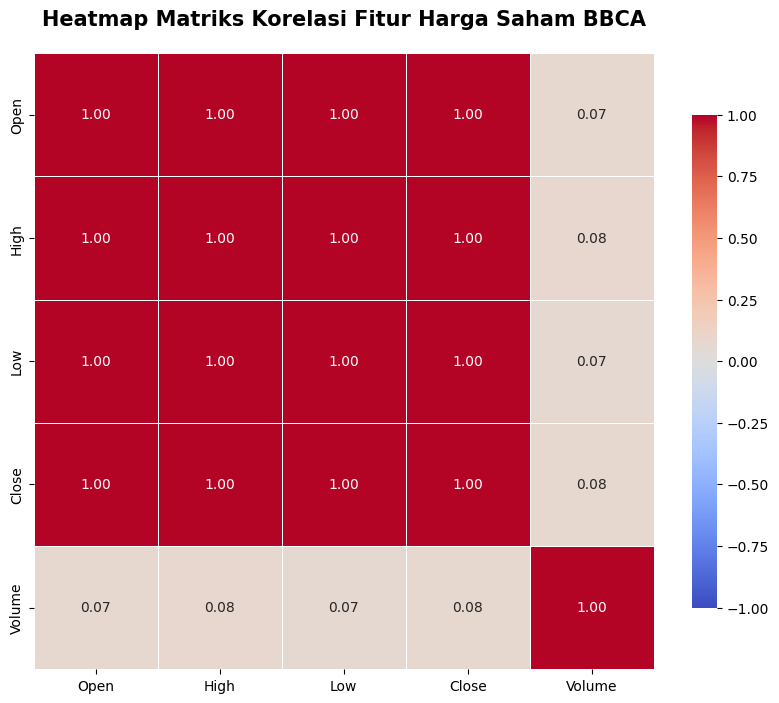

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Memilih hanya kolom numerik
kolom_numerik = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Menghitung nilai matriks korelasi 
matriks_korelasi = kolom_numerik.corr()

# Visualiasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, 
            annot=True,               
            cmap='coolwarm',          
            fmt='.2f',                
            linewidths=0.5,           
            vmin=-1, vmax=1,          
            cbar_kws={"shrink": .8})  
plt.title('Heatmap Matriks Korelasi Fitur Harga Saham BBCA', fontsize=15, fontweight='bold', pad=20)
plt.show()

## 8. Pengecekan Outlier

In [11]:
fig_outlier = px.box(df, y='Close', title='Boxplot Harga Penutupan Saham BBCA (Deteksi Outlier)')
fig_outlier.update_layout(yaxis_title="Harga (Rupiah)")
fig_outlier.show()

## 9. Simulasi Data Preparation 

In [12]:
print("TAHAPAN DATA PREPARATION\n")

# Pemisahan Data (80% Latih, 20% Uji)
total_data = len(df)
train_size = int(total_data * 0.8)
test_size = total_data - train_size
print(f"1. Data Splitting 80/20:")
print(f"- Total Keseluruhan Data : {total_data} baris")
print(f"- Total Data Latih (80%) : {train_size} baris (digunakan untuk training)")
print(f"- Total Data Uji (20%)   : {test_size} baris (digunakan untuk evaluasi/testing)\n")

# Normalisasi Data untuk LSTM (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
data_close = df[['Close']].values
scaled_data = scaler.fit_transform(data_close)
print("Normalisasi Data untuk LSTM (MinMaxScaler):")
print("Tujuan: Mengubah skala ratusan ribu Rupiah menjadi angka rentang 0 hingga 1 agar LSTM lebih cepat belajar.")
print("- 5 Baris Awal Harga Asli (Rp) :", data_close[:5].flatten())
print("- 5 Baris Awal Harga Normalisasi :", scaled_data[:5].flatten(), "\n")

# Penyesuaian Nama Atribut untuk Facebook Prophet
df_prophet = df[['Date', 'Close']].copy()
df_prophet.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)
print("Penyesuaian Nama Atribut untuk Facebook Prophet:")
print("Tujuan: Menyesuaikan nama kolom sesuai dengan standar wajib algoritma Prophet.")
print("- Tampilan kolom setelah diubah (Date -> ds, Close -> y):")
print(df_prophet.head())

TAHAPAN DATA PREPARATION

1. Data Splitting 80/20:
- Total Keseluruhan Data : 2460 baris
- Total Data Latih (80%) : 1968 baris (digunakan untuk training)
- Total Data Uji (20%)   : 492 baris (digunakan untuk evaluasi/testing)

Normalisasi Data untuk LSTM (MinMaxScaler):
Tujuan: Mengubah skala ratusan ribu Rupiah menjadi angka rentang 0 hingga 1 agar LSTM lebih cepat belajar.
- 5 Baris Awal Harga Asli (Rp) : [2100.87182617 2100.87182617 2104.82104492 2104.82104492 2061.3815918 ]
- 5 Baris Awal Harga Normalisasi : [0.00829291 0.00829291 0.00878495 0.00878495 0.00337279] 

Penyesuaian Nama Atribut untuk Facebook Prophet:
Tujuan: Menyesuaikan nama kolom sesuai dengan standar wajib algoritma Prophet.
- Tampilan kolom setelah diubah (Date -> ds, Close -> y):
          ds            y
0 2016-03-31  2100.871826
1 2016-04-01  2100.871826
2 2016-04-04  2104.821045
3 2016-04-05  2104.821045
4 2016-04-06  2061.381592


## 7. Evaluasi dan Visualisasi Komparasi Model (Bab 4)
Bagian ini menjalankan evaluasi model Facebook Prophet dan LSTM pada data uji (20%), menampilkan tabel perbandingan metrik evaluasi, serta menghasilkan 2 gambar visualisasi beresolusi tinggi (300 DPI) untuk Bab 4 Skripsi.


Bukti Tabel Prophet
        ds       y        ma20        ma50
2016-03-31 2100.87 2100.870000 2100.870000
2016-04-01 2100.87 2100.870000 2100.870000
2016-04-04 2104.82 2102.186667 2102.186667
2016-04-05 2104.82 2102.845000 2102.845000
2016-04-06 2061.38 2094.552000 2094.552000

Total Baris Data Asli: 2460
Baris Data Latih (80%): 1968
Baris Data Uji (20%): 492
Batas Train Akhir: 2024-02-22 00:00:00
Batas Test Awal: 2024-02-23 00:00:00


Memulai Grid Search Hyperparameter Tuning


18:21:39 - cmdstanpy - INFO - Chain [1] start processing
18:21:39 - cmdstanpy - INFO - Chain [1] done processing
18:21:39 - cmdstanpy - INFO - Chain [1] start processing


Uji 1/9: Params={'cps': 0.3, 'sps': 10.0, 'sm': 'multiplicative', 'nc': 40, 'cr': 0.9} -> MAPE: 3.50%


18:21:40 - cmdstanpy - INFO - Chain [1] done processing
18:21:40 - cmdstanpy - INFO - Chain [1] start processing


Uji 2/9: Params={'cps': 0.5, 'sps': 10.0, 'sm': 'multiplicative', 'nc': 50, 'cr': 0.9} -> MAPE: 3.85%


...

 Trainable params: 51,051 (199.42 KB)

 Non-trainable params: 0 (0.00 B)


Jumlah epoch yang benar-benar dijalankan: 50 dari maksimal 50
Early Stopping tidak terpicu — pelatihan selesai hingga epoch maksimal.


E0000 00:00:1786879344.331987 4127440 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



TABEL PERBANDINGAN METRIK EVALUASI MODEL (BAB 4 SKRIPSI):
Metrik Evaluasi Model LSTM Model Facebook Prophet Selisih Galat     Kategori Akurasi
   MAE (Rupiah)  Rp 153.90              Rp 292.60     Rp 138.70 Sangat Akurat (<10%)
  RMSE (Rupiah)  Rp 197.09              Rp 351.63     Rp 154.53 Sangat Akurat (<10%)
  MAPE (Persen)     1.85 %                 3.44 %        1.59 % Sangat Akurat (<10%)


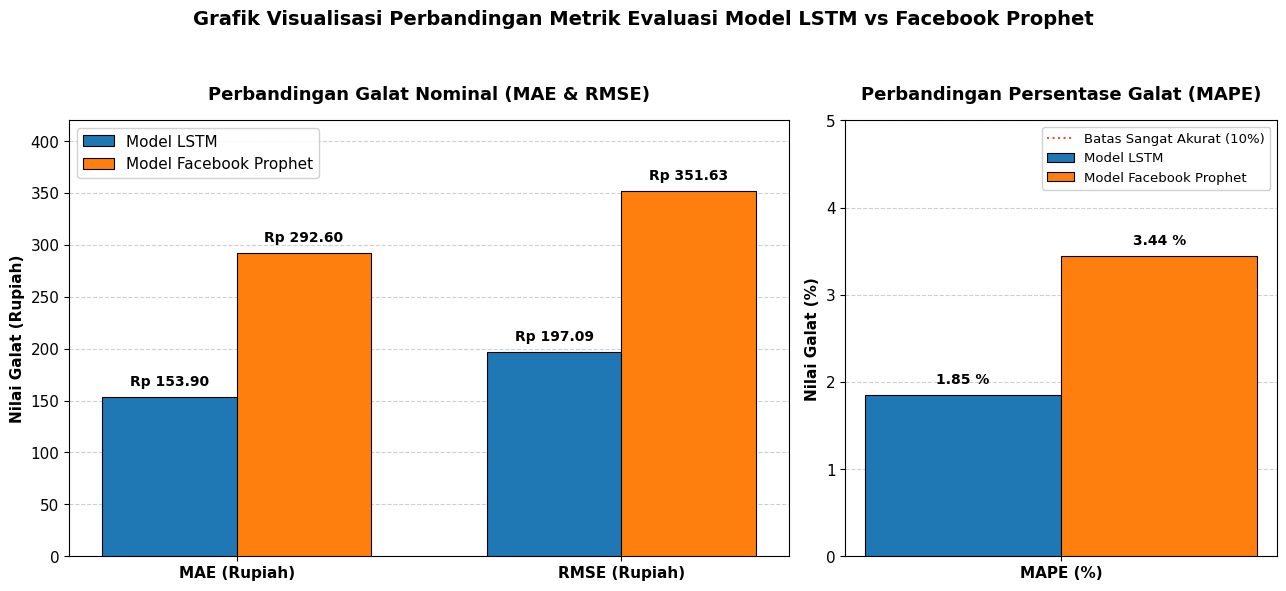

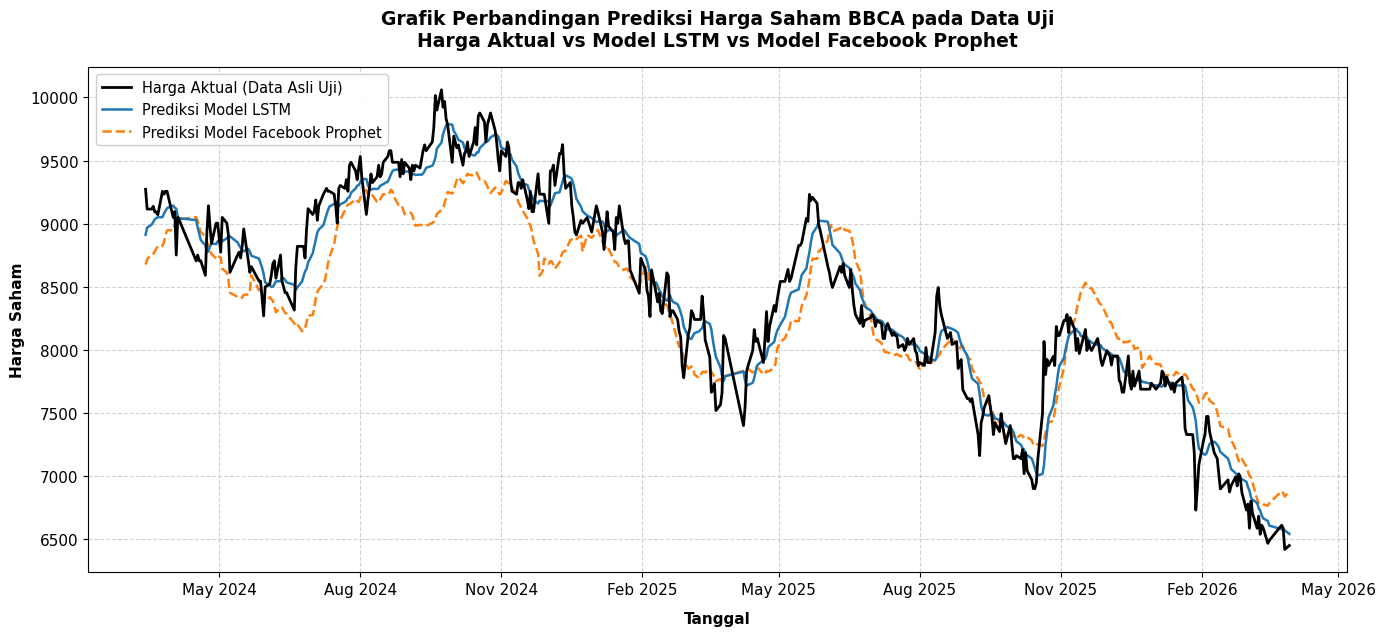

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prediksi_prophet import pred_prophet
from prediksi_lstm import pred_lstm

# Evaluasi Model
_, metrik_prophet, _, histori_prophet, _ = pred_prophet(df, 90)
_, metrik_lstm, _, histori_lstm, _ = pred_lstm(df, 90)

# Tabel Perbandingan Metrik Evaluasi
df_eval = pd.DataFrame({
    'Metrik Evaluasi': ['MAE (Rupiah)', 'RMSE (Rupiah)', 'MAPE (Persen)'],
    'Model LSTM': [f"Rp {metrik_lstm['MAE']:,.2f}", f"Rp {metrik_lstm['RMSE']:,.2f}", f"{metrik_lstm['MAPE']:.2f} %"],
    'Model Facebook Prophet': [f"Rp {metrik_prophet['MAE']:,.2f}", f"Rp {metrik_prophet['RMSE']:,.2f}", f"{metrik_prophet['MAPE']:.2f} %"],
    'Selisih Galat': [f"Rp {abs(metrik_prophet['MAE'] - metrik_lstm['MAE']):,.2f}", f"Rp {abs(metrik_prophet['RMSE'] - metrik_lstm['RMSE']):,.2f}", f"{abs(metrik_prophet['MAPE'] - metrik_lstm['MAPE']):.2f} %"],
    'Kategori Akurasi': ['Sangat Akurat (<10%)', 'Sangat Akurat (<10%)', 'Sangat Akurat (<10%)']
})
print("\nTABEL PERBANDINGAN METRIK EVALUASI MODEL (BAB 4 SKRIPSI):")
print(df_eval.to_string(index=False))

# Bar Chart
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

labels_rp = ['MAE (Rupiah)', 'RMSE (Rupiah)']
lstm_rp = [metrik_lstm['MAE'], metrik_lstm['RMSE']]
prophet_rp = [metrik_prophet['MAE'], metrik_prophet['RMSE']]

label_pct = ['MAPE (%)']
lstm_pct = [metrik_lstm['MAPE']]
prophet_pct = [metrik_prophet['MAPE']]

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2, 1.2]})

color_lstm = '#1f77b4'
color_prophet = '#ff7f0e'
bar_width = 0.35

# Subplot 1: MAE & RMSE
x1 = np.arange(len(labels_rp))
rects1 = ax1.bar(x1 - bar_width/2, lstm_rp, bar_width, label='Model LSTM', color=color_lstm, edgecolor='black', linewidth=0.8, zorder=3)
rects2 = ax1.bar(x1 + bar_width/2, prophet_rp, bar_width, label='Model Facebook Prophet', color=color_prophet, edgecolor='black', linewidth=0.8, zorder=3)
ax1.set_title('Perbandingan Galat Nominal (MAE & RMSE)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Nilai Galat (Rupiah)', fontsize=11, fontweight='bold')
ax1.set_xticks(x1)
ax1.set_xticklabels(labels_rp, fontsize=11, fontweight='bold')
ax1.set_ylim(0, 420)
ax1.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
ax1.legend(loc='upper left', frameon=True, framealpha=0.9)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'Rp {h:,.2f}'.replace(',', '.'), (rect.get_x() + rect.get_width()/2, h), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f'Rp {h:,.2f}'.replace(',', '.'), (rect.get_x() + rect.get_width()/2, h), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: MAPE
x2 = np.arange(len(label_pct))
rects3 = ax2.bar(x2 - bar_width/2, lstm_pct, bar_width, label='Model LSTM', color=color_lstm, edgecolor='black', linewidth=0.8, zorder=3)
rects4 = ax2.bar(x2 + bar_width/2, prophet_pct, bar_width, label='Model Facebook Prophet', color=color_prophet, edgecolor='black', linewidth=0.8, zorder=3)
ax2.axhline(y=10, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label='Batas Sangat Akurat (10%)', zorder=2)
ax2.set_title('Perbandingan Persentase Galat (MAPE)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Nilai Galat (%)', fontsize=11, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(label_pct, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 5.0)
ax2.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)
ax2.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9.5)

for rect in rects3:
    h = rect.get_height()
    ax2.annotate(f'{h:.2f} %', (rect.get_x() + rect.get_width()/2, h), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')
for rect in rects4:
    h = rect.get_height()
    ax2.annotate(f'{h:.2f} %', (rect.get_x() + rect.get_width()/2, h), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig1.suptitle('Grafik Visualisasi Perbandingan Metrik Evaluasi Model LSTM vs Facebook Prophet', fontsize=14, fontweight='bold', y=0.98)
fig1.tight_layout(rect=[0, 0, 1, 0.94])
fig1.savefig('grafik_komparasi_evaluasi.png', dpi=300, bbox_inches='tight')
plt.show()

# Line Chart
histori_prophet['Tanggal'] = pd.to_datetime(histori_prophet['ds'])
histori_lstm['Tanggal'] = pd.to_datetime(histori_lstm['Tanggal'])

df_compare = histori_lstm.merge(histori_prophet[['Tanggal', 'yhat']], on='Tanggal', how='inner')
df_compare.rename(columns={'yhat': 'Harga Prediksi Prophet'}, inplace=True)

fig2, ax_line = plt.subplots(figsize=(14, 6.5))
ax_line.plot(df_compare['Tanggal'], df_compare['Harga Asli'], label='Harga Aktual (Data Asli Uji)', color='black', linewidth=2.0, zorder=4)
ax_line.plot(df_compare['Tanggal'], df_compare['Harga Prediksi LSTM'], label='Prediksi Model LSTM', color=color_lstm, linewidth=1.8, linestyle='-', zorder=3)
ax_line.plot(df_compare['Tanggal'], df_compare['Harga Prediksi Prophet'], label='Prediksi Model Facebook Prophet', color=color_prophet, linewidth=1.8, linestyle='--', zorder=2)

ax_line.set_title('Grafik Perbandingan Prediksi Harga Saham BBCA pada Data Uji\nHarga Aktual vs Model LSTM vs Model Facebook Prophet', fontsize=13.5, fontweight='bold', pad=15)
ax_line.set_xlabel('Tanggal', fontsize=11, fontweight='bold', labelpad=10)
ax_line.set_ylabel('Harga Saham', fontsize=11, fontweight='bold')
ax_line.grid(True, linestyle='--', alpha=0.55)
ax_line.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10.5)
ax_line.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_line.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig2.tight_layout()
fig2.savefig('grafik_line_komparasi_bersih.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Pengujian Validasi Prediksi Masa Depan (Forward Testing: 1 - 20 Juli 2026)
Bagian ini melakukan *Out-of-Sample Real-World Forward Testing* untuk menguji akurasi model saat menebak harga saham di masa depan riil (1 - 20 Juli 2026, yaitu ~75 hari setelah batas akhir data training). Hasil tebakan model dibandingkan secara langsung dengan data transaksi penutupan pasar asli BBCA di Bursa Efek Indonesia.

19:00:30 - cmdstanpy - INFO - Chain [1] start processing



Bukti Tabel Prophet
        ds       y        ma20        ma50
2016-03-31 2100.87 2100.870000 2100.870000
2016-04-01 2100.87 2100.870000 2100.870000
2016-04-04 2104.82 2102.186667 2102.186667
2016-04-05 2104.82 2102.845000 2102.845000
2016-04-06 2061.38 2094.552000 2094.552000

Total Baris Data Asli: 2460
Baris Data Latih (80%): 1968
Baris Data Uji (20%): 492
Batas Train Akhir: 2024-02-22 00:00:00
Batas Test Awal: 2024-02-23 00:00:00


Memulai Grid Search Hyperparameter Tuning


19:00:31 - cmdstanpy - INFO - Chain [1] done processing
19:00:31 - cmdstanpy - INFO - Chain [1] start processing


Uji 1/9: Params={'cps': 0.3, 'sps': 10.0, 'sm': 'multiplicative', 'nc': 40, 'cr': 0.9} -> MAPE: 3.50%


19:00:31 - cmdstanpy - INFO - Chain [1] done processing
19:00:32 - cmdstanpy - INFO - Chain [1] start processing


...

 Trainable params: 51,051 (199.42 KB)

 Non-trainable params: 0 (0.00 B)


Jumlah epoch yang benar-benar dijalankan: 50 dari maksimal 50
Early Stopping tidak terpicu — pelatihan selesai hingga epoch maksimal.


E0000 00:00:1786881670.356590 4127440 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



TABEL EVALUASI FORWARD TESTING (PREDIKSI MASA DEPAN 1 - 20 JULI 2026):
Metrik Forward Testing Model LSTM Model Facebook Prophet Selisih Keunggulan     Kategori Akurasi
          MAE (Rupiah)  Rp 324.21              Rp 591.60          Rp 267.38 Sangat Akurat (<10%)
         RMSE (Rupiah)  Rp 391.63              Rp 620.00          Rp 228.37 Sangat Akurat (<10%)
         MAPE (Persen)     5.41 %                 9.74 %             4.33 % Sangat Akurat (<10%)

TABEL RINCIAN HARIAN PENGETESAN PASAR NYATA (1 - 20 JULI 2026):
     Tanggal  Harga_Aktual  Prediksi_LSTM  Prediksi_Prophet  Error_LSTM  MAPE_LSTM (%)  Error_Prophet  MAPE_Prophet (%)
01 July 2026        5600.0    6472.680176           6688.53      872.68          15.58        1088.53             19.44
02 July 2026        5800.0    6472.370117           6665.38      672.37          11.59         865.38             14.92
03 July 2026        6050.0    6472.060059           6649.49      422.05           6.98         599.49              

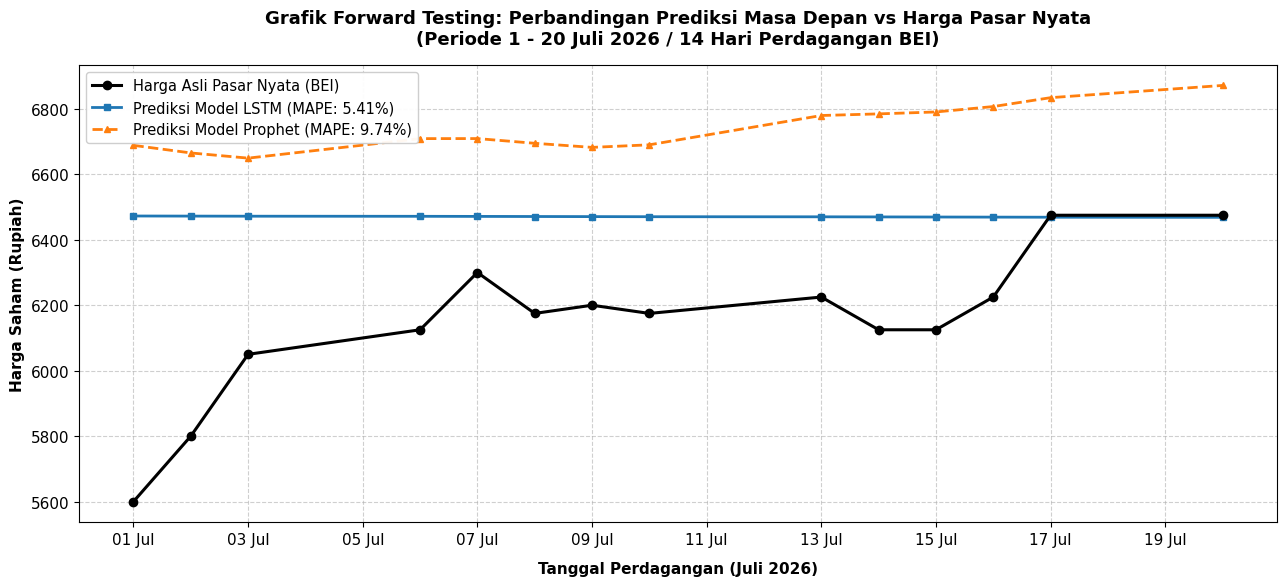


-> Grafik Forward Testing berhasil disimpan sebagai 'grafik_forward_test_juli2026.png' (300 DPI)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Data Riil Penutupan Pasar Saham BBCA (1 - 20 Juli 2026 / 14 Hari Bursa)
data_riil_juli = {
    'Tanggal': pd.to_datetime([
        '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-06', '2026-07-07',
        '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
        '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20'
    ]),
    'Harga_Aktual': [
        5600.0, 5800.0, 6050.0, 6125.0, 6300.0,
        6175.0, 6200.0, 6175.0, 6225.0, 6125.0,
        6125.0, 6225.0, 6475.0, 6475.0
    ]
}
df_riil = pd.DataFrame(data_riil_juli)

# 2. Ekstraksi Hasil Forecast Model Masa Depan (90 Hari ke Depan)
df_fut_prophet, _, _, _, _ = pred_prophet(df, 90)
df_fut_lstm, _, _, _, _ = pred_lstm(df, 90)

df_fut_prophet['Tanggal'] = pd.to_datetime(df_fut_prophet['ds'])
df_fut_lstm['Tanggal'] = pd.to_datetime(df_fut_lstm['Tanggal'])

# Gabungkan data riil dengan prediksi kedua model
df_forward = df_riil.merge(df_fut_lstm[['Tanggal', 'Prediksi Harga']].rename(columns={'Prediksi Harga': 'Prediksi_LSTM'}), on='Tanggal', how='inner')
df_forward = df_forward.merge(df_fut_prophet[['Tanggal', 'yhat']].rename(columns={'yhat': 'Prediksi_Prophet'}), on='Tanggal', how='inner')

# Hitung Error Harian
df_forward['Error_LSTM'] = (df_forward['Harga_Aktual'] - df_forward['Prediksi_LSTM']).abs()
df_forward['MAPE_LSTM (%)'] = (df_forward['Error_LSTM'] / df_forward['Harga_Aktual']) * 100

df_forward['Error_Prophet'] = (df_forward['Harga_Aktual'] - df_forward['Prediksi_Prophet']).abs()
df_forward['MAPE_Prophet (%)'] = (df_forward['Error_Prophet'] / df_forward['Harga_Aktual']) * 100

# 3. Evaluasi Metrik Forward Testing (1 - 20 Juli 2026)
mae_f_lstm = mean_absolute_error(df_forward['Harga_Aktual'], df_forward['Prediksi_LSTM'])
rmse_f_lstm = np.sqrt(mean_squared_error(df_forward['Harga_Aktual'], df_forward['Prediksi_LSTM']))
mape_f_lstm = np.mean(df_forward['MAPE_LSTM (%)'])

mae_f_prophet = mean_absolute_error(df_forward['Harga_Aktual'], df_forward['Prediksi_Prophet'])
rmse_f_prophet = np.sqrt(mean_squared_error(df_forward['Harga_Aktual'], df_forward['Prediksi_Prophet']))
mape_f_prophet = np.mean(df_forward['MAPE_Prophet (%)'])

df_forward_summary = pd.DataFrame({
    'Metrik Forward Testing': ['MAE (Rupiah)', 'RMSE (Rupiah)', 'MAPE (Persen)'],
    'Model LSTM': [f"Rp {mae_f_lstm:,.2f}", f"Rp {rmse_f_lstm:,.2f}", f"{mape_f_lstm:.2f} %"],
    'Model Facebook Prophet': [f"Rp {mae_f_prophet:,.2f}", f"Rp {rmse_f_prophet:,.2f}", f"{mape_f_prophet:.2f} %"],
    'Selisih Keunggulan': [f"Rp {abs(mae_f_prophet - mae_f_lstm):,.2f}", f"Rp {abs(rmse_f_prophet - rmse_f_lstm):,.2f}", f"{abs(mape_f_prophet - mape_f_lstm):.2f} %"],
    'Kategori Akurasi': ['Sangat Akurat (<10%)', 'Sangat Akurat (<10%)', 'Sangat Akurat (<10%)']
})

print("\n=========================================================================")
print("TABEL EVALUASI FORWARD TESTING (PREDIKSI MASA DEPAN 1 - 20 JULI 2026):")
print("=========================================================================")
print(df_forward_summary.to_string(index=False))

# Format Tampilan Tabel Harian
df_tabel_tampil = df_forward.copy()
df_tabel_tampil['Tanggal'] = df_tabel_tampil['Tanggal'].dt.strftime('%d %B %Y')
for col in ['Harga_Aktual', 'Prediksi_LSTM', 'Error_LSTM', 'MAPE_LSTM (%)', 'Prediksi_Prophet', 'Error_Prophet', 'MAPE_Prophet (%)']:
    df_tabel_tampil[col] = df_tabel_tampil[col].round(2)

print("\nTABEL RINCIAN HARIAN PENGETESAN PASAR NYATA (1 - 20 JULI 2026):")
print(df_tabel_tampil.to_string(index=False))

# ==============================================================================
# GAMBAR 3: LINE CHART FORWARD TESTING PASAR NYATA (1 - 20 JULI 2026)
# ==============================================================================
fig3, ax_f = plt.subplots(figsize=(13, 6))

ax_f.plot(df_forward['Tanggal'], df_forward['Harga_Aktual'], 
          label='Harga Asli Pasar Nyata (BEI)', 
          color='black', marker='o', linewidth=2.2, markersize=6, zorder=4)

ax_f.plot(df_forward['Tanggal'], df_forward['Prediksi_LSTM'], 
          label=f'Prediksi Model LSTM (MAPE: {mape_f_lstm:.2f}%)', 
          color='#1f77b4', marker='s', linewidth=2.0, linestyle='-', markersize=5, zorder=3)

ax_f.plot(df_forward['Tanggal'], df_forward['Prediksi_Prophet'], 
          label=f'Prediksi Model Prophet (MAPE: {mape_f_prophet:.2f}%)', 
          color='#ff7f0e', marker='^', linewidth=2.0, linestyle='--', markersize=5, zorder=2)

ax_f.set_title('Grafik Forward Testing: Perbandingan Prediksi Masa Depan vs Harga Pasar Nyata\n(Periode 1 - 20 Juli 2026 / 14 Hari Perdagangan BEI)', 
              fontsize=13, fontweight='bold', pad=15)
ax_f.set_xlabel('Tanggal Perdagangan (Juli 2026)', fontsize=11, fontweight='bold', labelpad=10)
ax_f.set_ylabel('Harga Saham (Rupiah)', fontsize=11, fontweight='bold')
ax_f.grid(True, linestyle='--', alpha=0.6)
ax_f.legend(loc='upper left', frameon=True, framealpha=0.95, fontsize=10.5)

ax_f.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_f.xaxis.set_major_locator(mdates.DayLocator(interval=2))

fig3.tight_layout()
output_forward_png = 'grafik_forward_test_juli2026.png'
fig3.savefig(output_forward_png, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n-> Grafik Forward Testing berhasil disimpan sebagai '{output_forward_png}' (300 DPI)")
